# M2 — Forwards and swaps: agreeing on future prices

A buyer can manage future compute prices through a fixed-price delivery contract or a separate financial agreement. The financial agreement pays or receives the difference between an agreed price and a future reference price. The compute itself must still be purchased.

Read [M1](04_the_tenor_trade.ipynb) first. Here a buyer needs **7,200 GPU-hours in month 12**. A seller supplies the same amount. All terms are **hypothetical**.

One choice is a physical agreement to deliver the computer time for USD 5 per hour. Another is to buy at the price then available, plus use a **cash-settled forward**. That separate contract exchanges money based on the price, but delivers no computer time.

Its agreed price, called the **strike**, is USD 5. We choose it for the example; we have not calculated a fair market price. We leave out fees, advance charges, collateral and failure to pay.

In [1]:
# Install the teaching package from GitHub when running in Google Colab.
# Local Jupyter uses the repository's existing environment.
import subprocess
import sys

if "google.colab" in sys.modules:
    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--quiet",
            "liquid-compute[colab] @ git+https://github.com/zach189/education.git@main",
        ]
    )
    from google.colab import output

    output.enable_custom_widget_manager()

In [2]:
from IPython.display import display

from liquid_compute.education import (
    explore_forward_hedge,
    plot_forward_hedge,
    show_finance_table,
)
from liquid_compute.hedging import (
    combined_physical_and_hedge_cash_flows,
    forward_settlements_usd,
)

physical_gpu_hours = 7_200
hedge_gpu_hours = 7_200
strike_usd_per_gpu_hour = 5.0
settlement_month = 12
show_finance_table(
    ["Arrangement", "Physical obligation", "Financial cash"],
    [
        [
            "Fixed physical delivery",
            "Deliver 7,200 GPU-hours in month 12",
            "Buyer pays USD 36,000",
        ],
        [
            "Spot plus cash-settled forward",
            "Separate spot purchase required",
            "Buyer receives H × (benchmark − strike)",
        ],
    ],
)

| Arrangement | Physical obligation | Financial cash |
| --- | --- | --- |
| Fixed physical delivery | Deliver 7,200 GPU-hours in month 12 | Buyer pays USD 36,000 |
| Spot plus cash-settled forward | Separate spot purchase required | Buyer receives H × (benchmark − strike) |

## Calculate the buyer’s financial settlement

At a reference price of USD 7, the forward pays the buyer **7,200 × (7 − 5) = USD 14,400**. The reference price used by the contract is called its **benchmark**.

Buying computer time costs **7,200 × 7 = USD 50,400**. Subtract the forward receipt and the buyer spends **USD 36,000 net**.

If the price falls below USD 5, the buyer pays money on the forward but buys cheaper computer time. Keep that negative settlement in the calculation. A forward is a two-way obligation, not a free choice to take only the good result. M5 introduces options.

In [3]:
benchmark_usd_per_gpu_hour = 7.0
settlement_received_usd = 7_200 * (7 - 5)
spot_cost_usd = 7_200 * 7
net_cost_usd = spot_cost_usd - settlement_received_usd
show_finance_table(
    ["Direct calculation", "USD"],
    [
        ["Spot physical cost", spot_cost_usd],
        ["Hedge cash received", settlement_received_usd],
        ["Net buyer cost", net_cost_usd],
    ],
)

| Direct calculation | USD |
| --- | --- |
| Spot physical cost | 50,400.00 |
| Hedge cash received | 14,400.00 |
| Net buyer cost | 36,000.00 |

The combined cost is USD 5 per hour because the purchased hours, covered hours and both prices match exactly.

The USD 14,400 receipt is money, not computer capacity. The buyer still needs to find and purchase the compute.

## Compare three possible settlement prices

Use USD 3, USD 5 and USD 7 as three separate possible outcomes in month 12. They are not three payments on one contract.

Keep the physical purchase and financial settlement separate. Money received is positive; money paid is negative. A **hedge** is the separate agreement used here to reduce price risk.

In [4]:
def buyer_case(
    price,
    hours=hedge_gpu_hours,
    strike=strike_usd_per_gpu_hour,
    quantity=physical_gpu_hours,
):
    settlements = forward_settlements_usd(
        benchmark_usd_per_gpu_hour=[price],
        strike_usd_per_gpu_hour=strike,
        hedge_gpu_hours=[hours],
        settlement_months=[12],
        side="buyer",
    )
    return combined_physical_and_hedge_cash_flows(
        physical_usd_per_gpu_hour=[price],
        physical_gpu_hours=[quantity],
        physical_payment_months=[12],
        settlements=settlements,
        side="buyer",
    )


prices = (3.0, 5.0, 7.0)
show_finance_table(
    [
        "Benchmark (USD/GPU-hour)",
        "Spot cost (USD)",
        "Buyer hedge receipt (USD)",
        "Net cost (USD)",
    ],
    [
        [
            price,
            -buyer_case(price)[12].physical_cash_usd,
            buyer_case(price)[12].hedge_cash_usd,
            -buyer_case(price)[12].net_cash_usd,
        ]
        for price in prices
    ],
)

| Benchmark (USD/GPU-hour) | Spot cost (USD) | Buyer hedge receipt (USD) | Net cost (USD) |
| --- | --- | --- | --- |
| 3.00 | 21,600.00 | -14,400.00 | 36,000.00 |
| 5.00 | 36,000.00 | 0.00 | 36,000.00 |
| 7.00 | 50,400.00 | 14,400.00 | 36,000.00 |

The forward settlements are **−USD 14,400, zero and +USD 14,400**. The buyer's combined cost is **USD 36,000** in all three cases.

A fixed-price physical delivery also costs USD 36,000. It is an alternative choice. Do not buy it on top of the spot purchase and forward and count the compute twice.

The chart moves across possible prices, not months. A flat cost line means these price changes do not change combined cost. It does not guarantee delivery or payment by the other party.

The optional controls change the strike and covered hours while the buyer still needs 7,200 hours. Each panel keeps its own inputs; editable cells are also available.

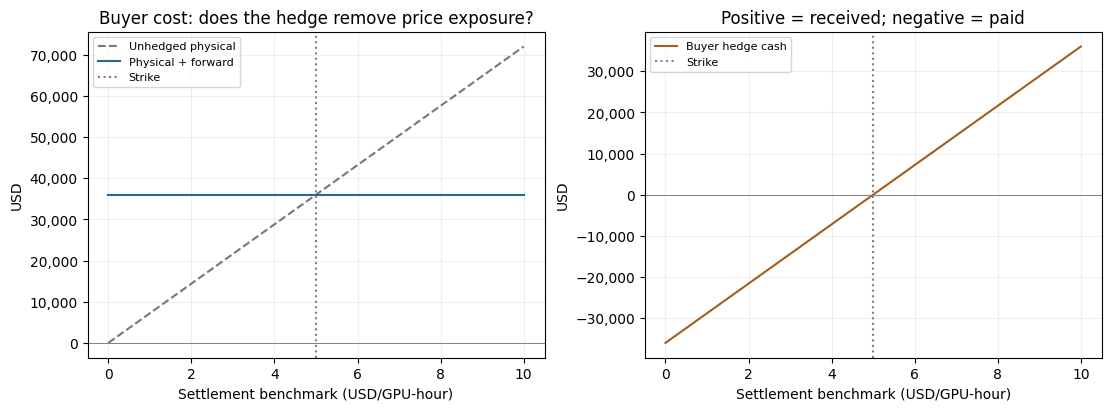

In [5]:
display(
    plot_forward_hedge(
        physical_gpu_hours=physical_gpu_hours,
        hedge_gpu_hours=hedge_gpu_hours,
        strike_usd_per_gpu_hour=strike_usd_per_gpu_hour,
    )
)
explore_forward_hedge(
    physical_gpu_hours=physical_gpu_hours,
    hedge_gpu_hours=hedge_gpu_hours,
    strike_usd_per_gpu_hour=strike_usd_per_gpu_hour,
);

The left chart compares the total physical cost or receipts with and without the forward. The right chart separates the hedge cash: above zero is received, below zero is paid. Both legs settle on the same assumed date. Try half coverage, then switch from buyer to seller. An oversized hedge reverses the exposure instead of eliminating it. Reset restores the editable starting assumptions.

Matching the hours makes the cost line flat. Raising the strike raises the flat cost. Covering a different number of hours usually makes cost vary with price again.

These are payment calculations for chosen terms. They do not tell us what strike a real provider would offer.

## Experiment 1 — Reverse the hedge direction for a seller

The seller gets the opposite forward settlement. When prices rise, it earns more from selling compute but pays on the hedge. When prices fall, it earns less from compute but receives hedge money.

In [6]:
seller_results = []
for price in prices:
    settlements = forward_settlements_usd(
        benchmark_usd_per_gpu_hour=[price],
        strike_usd_per_gpu_hour=5,
        hedge_gpu_hours=[7_200],
        settlement_months=[12],
        side="seller",
    )
    rows = combined_physical_and_hedge_cash_flows(
        physical_usd_per_gpu_hour=[price],
        physical_gpu_hours=[7_200],
        physical_payment_months=[12],
        settlements=settlements,
        side="seller",
    )
    seller_results.append(
        [
            price,
            rows[12].physical_cash_usd,
            rows[12].hedge_cash_usd,
            rows[12].net_cash_usd,
        ]
    )
show_finance_table(
    [
        "Price (USD/GPU-hour)",
        "Physical receipt (USD)",
        "Seller hedge receipt (USD)",
        "Net receipt (USD)",
    ],
    seller_results,
)

| Price (USD/GPU-hour) | Physical receipt (USD) | Seller hedge receipt (USD) | Net receipt (USD) |
| --- | --- | --- | --- |
| 3.00 | 21,600.00 | 14,400.00 | 36,000.00 |
| 5.00 | 36,000.00 | -0.00 | 36,000.00 |
| 7.00 | 50,400.00 | -14,400.00 | 36,000.00 |

The buyer's and seller's forward settlements add to zero: one side pays what the other receives.

The seller's combined receipt is **USD 36,000**, matching the buyer's cost. The agreement does not create extra money for both sides.

## Experiment 2 — Settle a swap over three months

Now use USD 3, USD 5 and USD 7 as actual prices in months 12, 13 and 14. Each month covers 7,200 hours at a USD 5 strike. This series of settlements is our simple **swap**.

The financial payments add to zero, but they happen on different dates. That matters if we need money to make the first payment.

In [7]:
strip = forward_settlements_usd(
    benchmark_usd_per_gpu_hour=[3, 5, 7],
    strike_usd_per_gpu_hour=5,
    hedge_gpu_hours=[7_200] * 3,
    settlement_months=[12, 13, 14],
    side="buyer",
)
show_finance_table(
    ["Settlement month", "Buyer cash received (USD)"],
    [[r.month_offset, r.amount_usd] for r in strip],
)
print(f"Net financial settlement: USD {sum(r.amount_usd for r in strip):,.0f}")

| Settlement month | Buyer cash received (USD) |
| --- | --- |
| 12.00 | -14,400.00 |
| 13.00 | 0.00 |
| 14.00 | 14,400.00 |

Net financial settlement: USD 0


The buyer pays **USD 14,400 in month 12** and receives **USD 14,400 in month 14**. Later money cannot pay an earlier bill unless cash is available from somewhere else.

M7 will examine early cash needs and collateral. This swap uses only the monthly payment dates stated here.

## Experiment 3 — Protect half the hours

Cover **3,600 hours** while buying 7,200. Half the price risk remains. The forward does not automatically resize when the buyer's needs change.

In [8]:
show_finance_table(
    [
        "Benchmark (USD/GPU-hour)",
        "Unhedged cost (USD)",
        "Half-hedged cost (USD)",
        "Fully hedged cost (USD)",
    ],
    [
        [
            price,
            7_200 * price,
            -buyer_case(price, hours=3_600)[12].net_cash_usd,
            -buyer_case(price)[12].net_cash_usd,
        ]
        for price in prices
    ],
)

| Benchmark (USD/GPU-hour) | Unhedged cost (USD) | Half-hedged cost (USD) | Fully hedged cost (USD) |
| --- | --- | --- | --- |
| 3.00 | 21,600.00 | 28,800.00 | 36,000.00 |
| 5.00 | 36,000.00 | 36,000.00 | 36,000.00 |
| 7.00 | 50,400.00 | 43,200.00 | 36,000.00 |

For prices of USD 3, USD 5 and USD 7, half-covered costs are **USD 28,800, USD 36,000 and USD 43,200**.

The buyer benefits from some of a price fall, but still pays more when prices rise. These results sit between buying without a hedge and fully matching the hours.

Our full price lock works only when the reference price matches the actual price, the quantities match and the contracts perform as assumed. Next we deliberately break those matches.

In [9]:
show_finance_table(
    ["Arrangement", "Hedge GPU-hours", "Financial settlement dates"],
    [
        ["One matched forward", 7_200, "Month 12"],
        ["Half coverage", 3_600, "Month 12"],
        ["Three-month strip", 7_200, "Months 12, 13 and 14; quantity each month"],
    ],
)

| Arrangement | Hedge GPU-hours | Financial settlement dates |
| --- | --- | --- |
| One matched forward | 7,200.00 | Month 12 |
| Half coverage | 3,600.00 | Month 12 |
| Three-month strip | 7,200.00 | Months 12, 13 and 14; quantity each month |

## Next — Does the reference price match our bill?

Continue to **M3: Choosing a benchmark and managing basis risk**.

[CME's futures/forwards comparison](https://www.cmegroup.com/education/courses/introduction-to-futures/futures-contracts-compared-to-forwards) explains future-price agreements. Its [cash-flow discussion](https://www.cmegroup.com/education/courses/introduction-to-base-metals/cash-flow-in-metals-futures-vs-forwards) explains different payment timing. These describe concepts, not a compute contract available to buy. We have not added exchange margin rules to our privately agreed example.